# **Total Perspective Vortex**
## **Goals**
**Total perspective vortex** is a 42 school project, which goal is to create a brain computer interface based on the **EEG** (electroencephalogram) data from [physionet](https://physionet.org/content/eegmmidb/1.0.0/).
The main goal is to create a [**dimensionality reduction algorithm**](https://en.wikipedia.org/wiki/Dimensionality_reduction) and create a **benchmark** with different **machine learning (ML)** algorithm, using **scikit learn** **pipeline object**.

Those ML **algorithm** will be used to **predict**, in real time, which **movement** the patient will do (move his feets. his hands, ...).

## **Resources**
### EEG data
- [The project data set.](https://physionet.org/content/eegmmidb/1.0.0/S001/#files-panel)
- [Physionet signal visualizer.](https://physionet.org/lightwave/?db=eegmmidb/1.0.0)
- [MNE website.](https://mne.tools/stable/index.html)
- [Article that explain some preprocessing of the dataset](https://pmc.ncbi.nlm.nih.gov/articles/PMC10998040/pdf/main.pdf)
- [GitHub of a EEG motor imagery classification](https://github.com/arshc0der/EEG-Motor-Imagery-Classification)
- [Explanation of BCI and it's data](https://github.com/RezaSaadatyar/Motor-imagery-based-EEG-signal-processing)
### Data filtering
- [Article that explain data filtering.](https://medium.com/@acamvproducingstudio/how-do-filters-work-and-how-to-simulate-them-signals-and-systems-review-part4-f6a978cefca3)
- [Wikipedia page of the low pass filter](https://en.wikipedia.org/wiki/Low-pass_filter)
- [MNE explanation of filtering](https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html)
### Dimensionality reduction
- [Dimensionality reduction Wikipedia page.](https://en.wikipedia.org/wiki/Dimensionality_reduction)
- [IBM article about dimensionality reduction.](https://www.ibm.com/think/topics/dimensionality-reduction)
- [Article with explanation and use of different dimensionality reduction.](https://pmc.ncbi.nlm.nih.gov/articles/PMC12453773/)
### Wavelet Transform
- [Article which explain what is the Wavelet Transform](https://towardsdatascience.com/the-wavelet-transform-e9cfa85d7b34/)

In [2]:
import numpy as np
import mne
import pathlib as pth
import matplotlib.pyplot as plt
from dataclasses import dataclass

from filter import low_pass_filter, band_pass_filter

# 1.0 Extracting the data.

### Dataset description:
The current data set is composed of 109 subjects that where tested, with 14 test, each with 64 electrodes.
So in terms of architecture, it looks like this:
```
S001
├── S001R01.edf
│   └── data shape -> (64, ...)
├── S001R01.edf.event
[...]
├── S001R14.edf
│   └── data shape -> (64, ...)
└── S001R14.edf.event
```

Each test are split in 3 different parts: T0 (Idle), T1 (Action 1), T2 (Action 2).

Each test are done in range of 2 minutes.

In [3]:
data_folder = pth.Path('eeg-motor-movementimagery-dataset-1.0.0/files')

# Change with a iterdir loop or a data selector.
s001 = data_folder / 'S001'

s001r01 = s001 / 'S001R06.edf'
raw = mne.io.read_raw_edf(s001r01)
raw_events = mne.events_from_annotations(raw)

data = raw.get_data()

@dataclass(frozen=True)
class Event:
    type:       int
    type_str:   str
    arr:        np.ndarray
    time:       np.ndarray

split_events = [
    Event(
        start[2],
        list(raw_events[1].keys())[list(raw_events[1].values()).index(start[2])],
        data[:, start[0]:end[0]],
        raw.times[start[0]:end[0]]
    ) for start, end in zip(raw_events[0][:-1, :], raw_events[0][1:, :])]

Extracting EDF parameters from eeg-motor-movementimagery-dataset-1.0.0/files/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


## 1.1 Data analyse
### Raw signal

Since we now have extracted the raw data of the file, we can see what the signals look like.

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2331022/1412620096.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot()
/home/mhaouas/Documents/42PostCC/total-perspective-vortex/.venv/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


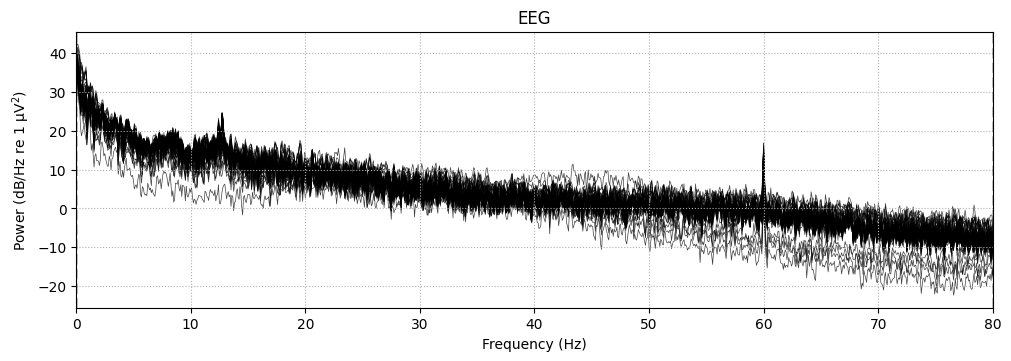

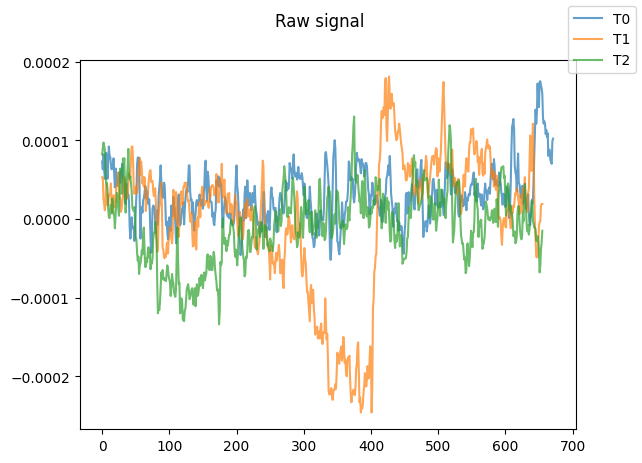

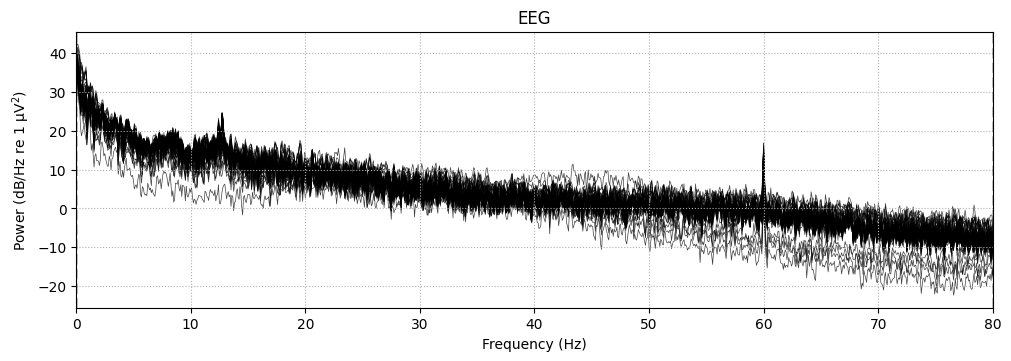

In [4]:
fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')

first_t0, time_t0 = next((event.arr, event.time) for event in split_events if event.type_str == 'T0')
first_t1, time_t1 = next((event.arr, event.time) for event in split_events if event.type_str == 'T1')
first_t2, time_t2 = next((event.arr, event.time) for event in split_events if event.type_str == 'T2')

sig_plt.plot(first_t0[0], label='T0', alpha=0.7)
sig_plt.plot(first_t1[0], label='T1', alpha=0.7)
sig_plt.plot(first_t2[0], label='T2', alpha=0.7)

fig.legend()

raw.compute_psd(fmax=80).plot()


# 2.0 Filter data
We can see that there is a lot of information on the raw data, but there is also a lot of noises.

Now, the goal is to remove as much noise as possible.

To see where the noise come from, we'll use the Fourier Transform. It's a formula that transforms signals from the time axis, to spectrum on the frequency axis. With it, we can see which frequencies are more present than the other, and filter to only keep them.

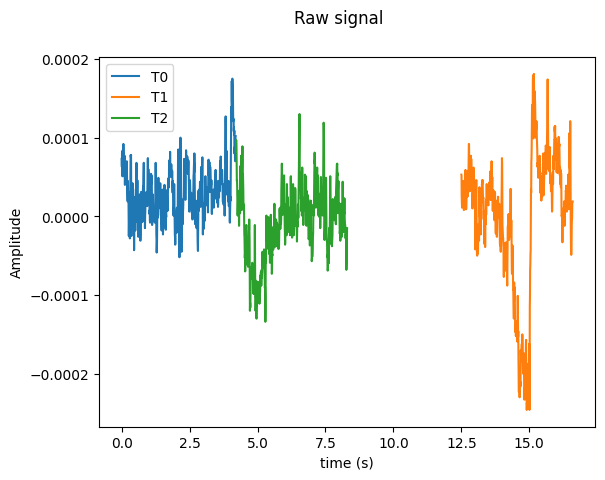

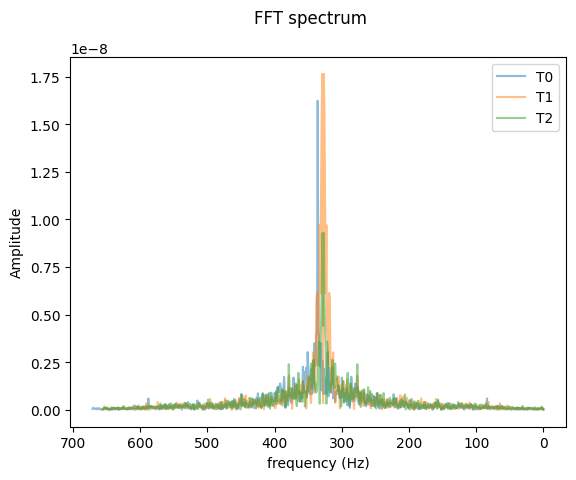

In [5]:

fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')
sig_plt.plot(time_t0, first_t0[0], label='T0')
sig_plt.plot(time_t1, first_t1[0], label='T1')
sig_plt.plot(time_t2, first_t2[0], label='T2')
sig_plt.set_xlabel('time (s)')
sig_plt.set_ylabel('Amplitude')
sig_plt.legend()

fig, fft_plt = plt.subplots(1, 1)
fig.suptitle('FFT spectrum')
# Since fft need imaginary numbers, if not provided it mirror the values.
# The first half is the positive component, and the last half is the negative components.

x_axis_val = np.arange(-raw.info["sfreq"], raw.info["sfreq"], (raw.info["sfreq"] * 2) / data.shape[1])

fft_t0 = np.abs(np.fft.fftshift(np.fft.fft(first_t0[0]))) / data.size
fft_t1 = np.abs(np.fft.fftshift(np.fft.fft(first_t1[0]))) / data.size
fft_t2 = np.abs(np.fft.fftshift(np.fft.fft(first_t2[0]))) / data.size
fft_plt.plot(fft_t0.real, alpha=0.5, label='T0')
fft_plt.plot(fft_t1.real, alpha=0.5, label='T1')
fft_plt.plot(fft_t2.real, alpha=0.5, label='T2')

fft_plt.legend()
fft_plt.xaxis.set_inverted(True)
fft_plt.set_xlabel('frequency (Hz)')
fft_plt.set_ylabel('Amplitude')
# fft_plt.plot(np.random.uniform(-160, 160, data.shape[1]), fft_data.real)
plt.show()


With this spectrum, we can see that the majority of the data is at a low frequency (Center of the plot).

We're lucky, because there is a signal filtering algorithm that remove the high frequencies and keep only the low ones.

It's called the **_Low Pass Filter_**.

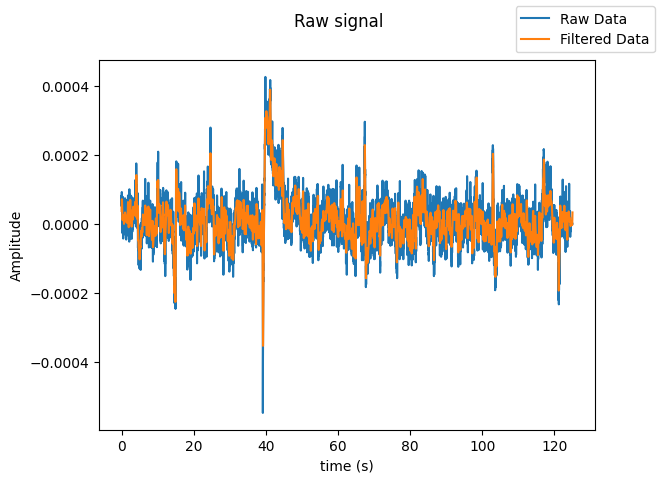

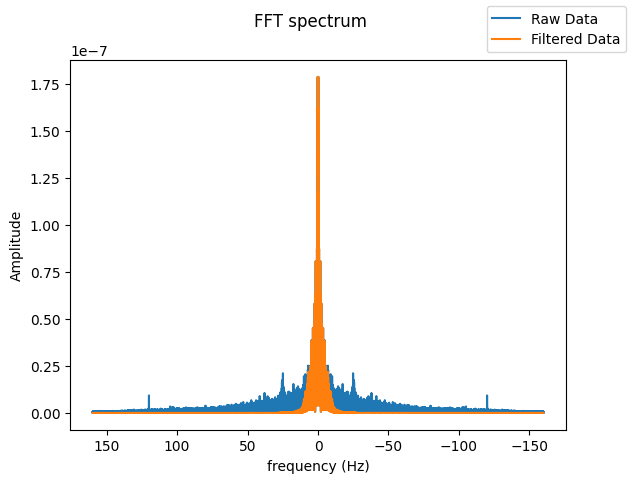

In [6]:
filtered_data = low_pass_filter(data[0:1, :], 500)[0]

fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')

sig_plt.plot(raw.times, data[0, :], label="Raw Data")
sig_plt.plot(raw.times, filtered_data, label="Filtered Data")
sig_plt.set_xlabel('time (s)')
sig_plt.set_ylabel('Amplitude')

fig.legend()

fig, fft_plt = plt.subplots(1, 1)
fig.suptitle('FFT spectrum')
# Since fft need imaginary numbers, if not provided it mirror the values.
# The first half is the positive component, and the last half is the negative components.

x_axis_val = np.arange(-raw.info["sfreq"], raw.info["sfreq"], (raw.info["sfreq"] * 2) / data.shape[1])

fft_data = np.abs(np.fft.fftshift(np.fft.fft(data[0, :]))) / data.size
fft_filtered_data = np.abs(np.fft.fftshift(np.fft.fft(filtered_data))) / data.size
fft_plt.plot(x_axis_val, fft_data.real, label="Raw Data")
fft_plt.plot(x_axis_val, fft_filtered_data.real, label="Filtered Data")
fft_plt.xaxis.set_inverted(True)
fft_plt.set_xlabel('frequency (Hz)')
fft_plt.set_ylabel('Amplitude')

fig.legend()
# fft_plt.plot(np.random.uniform(-160, 160, data.shape[1]), fft_data.real)
plt.show()

Like showed here, on the FFT spectrum, the filtered data keep only low frequency and smoothly remove the higher frequencies.

But after [some research](https://github.com/RezaSaadatyar/Motor-imagery-based-EEG-signal-processing), we can see that the important frequency are divided in three parts:
- **SMR (8-13 Hz)**: It represents a desynchronization (reduction in power) of the imagined movement. _For example, imagining moving the right hand leads to desynchronization in the left sensorimotor cortex._
- **Beta Band (13 - 30 Hz)**: The beta band, especially the lower beta range (13 - 30 Hz), is associated with motor planning and execution. In motor imagery tasks, an increase in beta power is observed over the motor cortex corresponding to the imagined movement.
- **Gamma Band (30 - 100 Hz)**: Gamma activity (30 - 100 Hz) is linked to complex cognitive functions and is involved in the binding of different brain regions. It can also be modulated during motor imagery tasks, particularly in tasks that involve detailed mental representations of movements.

But the **Gamma Band** is linked to more complex function, it won't be important for now.

So we'll need to filter the signal, again, but this time with the corresponding range (8-30 Hz). To do so, we'll use an other filter called the **Band Pass Filter**.

(1, 20000)


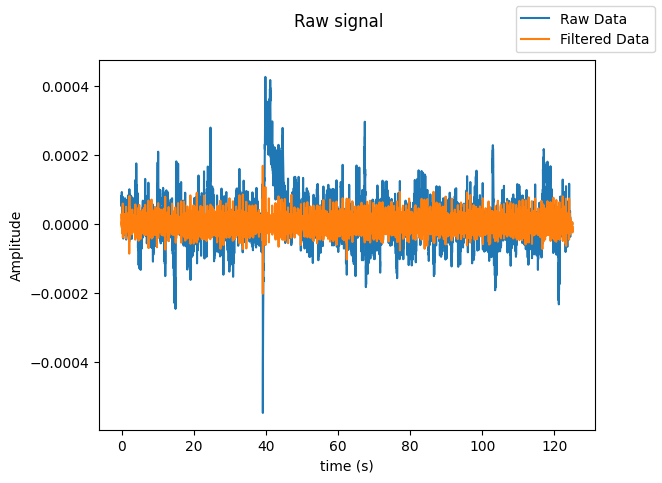

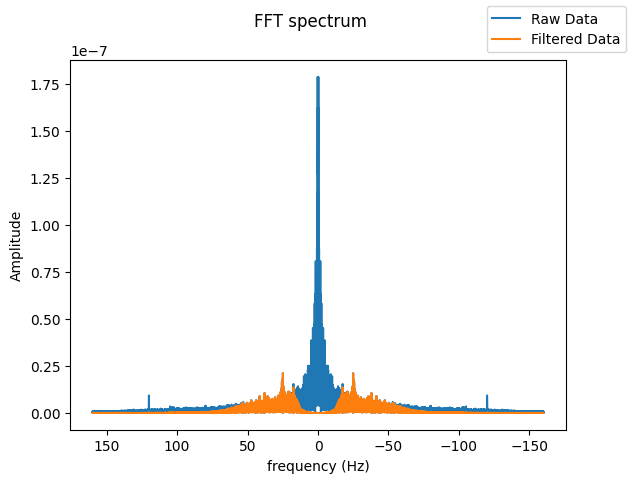

In [7]:
filtered_data = band_pass_filter(data[0:1, :], 8, 30, 160)[0]

print(data[0:1, :].shape)

fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')

sig_plt.plot(raw.times, data[0, :], label="Raw Data")
sig_plt.plot(raw.times, filtered_data, label="Filtered Data")
sig_plt.set_xlabel('time (s)')
sig_plt.set_ylabel('Amplitude')

fig.legend()

fig, fft_plt = plt.subplots(1, 1)
fig.suptitle('FFT spectrum')

x_axis_val = np.arange(-raw.info["sfreq"], raw.info["sfreq"], (raw.info["sfreq"] * 2) / data.shape[1])

fft_data = np.abs(np.fft.fftshift(np.fft.fft(data[0, :]))) / data.size
fft_filtered_data = np.abs(np.fft.fftshift(np.fft.fft(filtered_data))) / data.size
fft_plt.plot(x_axis_val, fft_data.real, label="Raw Data")
fft_plt.plot(x_axis_val, fft_filtered_data.real, label="Filtered Data")
fft_plt.xaxis.set_inverted(True)
fft_plt.set_xlabel('frequency (Hz)')
fft_plt.set_ylabel('Amplitude')

fig.legend()
# fft_plt.plot(np.random.uniform(-160, 160, data.shape[1]), fft_data.real)
plt.show()

Now, let's check what it look like with splitted data.

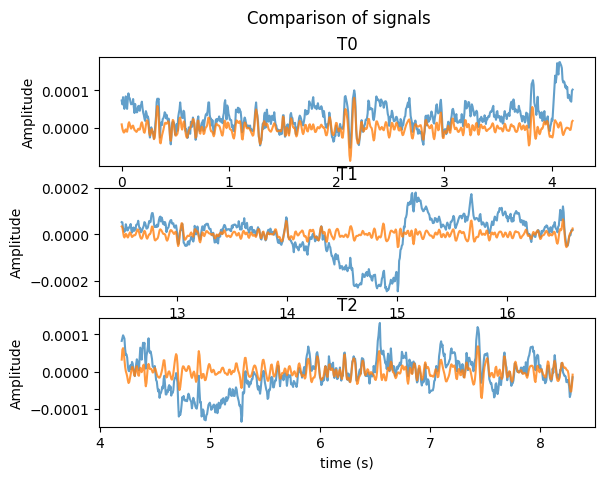

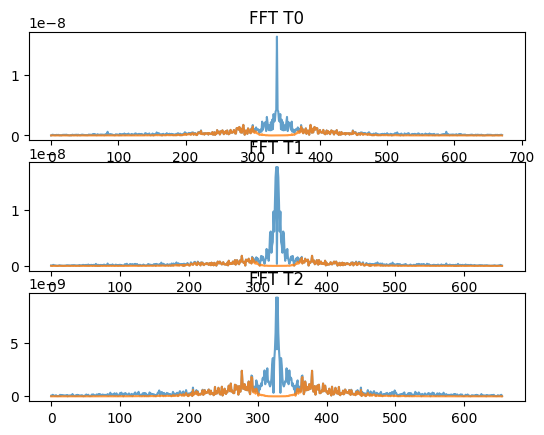

In [8]:
fig, (sig_plt_0, sig_plt_1, sig_plt_2) = plt.subplots(3, 1)

first_t0_filtered = band_pass_filter(first_t0[0].reshape(1, -1), 8, 30, 160).squeeze()
first_t1_filtered = band_pass_filter(first_t1[0].reshape(1, -1), 8, 30, 160).squeeze()
first_t2_filtered = band_pass_filter(first_t2[0].reshape(1, -1), 8, 30, 160).squeeze()

fig.suptitle('Comparison of signals')
sig_plt_0.set_title('T0')
sig_plt_0.plot(time_t0, first_t0[0], alpha=0.7, label='RAW')
sig_plt_0.plot(time_t0, first_t0_filtered, alpha=0.8, label='Filtered')

sig_plt_1.set_title('T1')
sig_plt_1.plot(time_t1, first_t1[0], alpha=0.7, label='RAW')
sig_plt_1.plot(time_t1, first_t1_filtered, alpha=0.8, label='Filtered')

sig_plt_2.set_title('T2')
sig_plt_2.plot(time_t2, first_t2[0], alpha=0.7, label='RAW')
sig_plt_2.plot(time_t2, first_t2_filtered, alpha=0.8, label='Filtered')

sig_plt_0.set_xlabel('time (s)')
sig_plt_0.set_ylabel('Amplitude')
sig_plt_1.set_xlabel('time (s)')
sig_plt_1.set_ylabel('Amplitude')
sig_plt_2.set_xlabel('time (s)')
sig_plt_2.set_ylabel('Amplitude')

fig, (fft_plt_0, fft_plt_1, fft_plt_2) = plt.subplots(3, 1)

x_axis_val = np.arange(-raw.info["sfreq"], raw.info["sfreq"], (raw.info["sfreq"] * 2) / data.shape[1])

fft_t0 = np.abs(np.fft.fftshift(np.fft.fft(first_t0[0]))) / data.size
fft_t0_filtered = np.abs(np.fft.fftshift(np.fft.fft(first_t0_filtered))) / data.size

fft_t1 = np.abs(np.fft.fftshift(np.fft.fft(first_t1[0]))) / data.size
fft_t1_filtered = np.abs(np.fft.fftshift(np.fft.fft(first_t1_filtered))) / data.size

fft_t2 = np.abs(np.fft.fftshift(np.fft.fft(first_t2[0]))) / data.size
fft_t2_filtered = np.abs(np.fft.fftshift(np.fft.fft(first_t2_filtered))) / data.size

fft_plt_0.set_title('FFT T0')
fft_plt_0.plot(fft_t0.real, alpha=0.7)
fft_plt_0.plot(fft_t0_filtered.real, alpha=0.8)

fft_plt_1.set_title('FFT T1')
fft_plt_1.plot(fft_t1.real, alpha=0.7)
fft_plt_1.plot(fft_t1_filtered.real, alpha=0.8)

fft_plt_2.set_title('FFT T2')
fft_plt_2.plot(fft_t2.real, alpha=0.7)
fft_plt_2.plot(fft_t2_filtered.real, alpha=0.8)

fft_plt.xaxis.set_inverted(True)
fft_plt.set_xlabel('frequency (Hz)')
fft_plt.set_ylabel('Amplitude')
# fft_plt.plot(np.random.uniform(-160, 160, data.shape[1]), fft_data.real)
plt.show()


It's a lot less noise, and we can see that the signals are really different, which will help a lot to differentiate the three categories.

# 3.0 Preparation of Data

Now that we've cleaned our data, we need to prepare it for our classification algorithm.

To do so, we need to cut our signals in smaller part, and to labelize it.

We know that each subjects (S001, S002, ...) have 14 recording (S001R01, S001R02, ...).

On those 14 recording, the first two are baseline with only "rest" recording, we don't need them for training.

For the rest of the data, We have 4 different types of recording:
- Imagining the movement for one fist (Left / Right).
- Doing the movement for one fist (Left / Right).
- Imagining the movement of both fist or both feets.
- Doing the movement of both fist or both feets.

With some research, we found that the order is quite simple, each type are done in order.

So we have:
- Run 01 and 02 -> Baseline
- Run 03, 07, 11 -> Imagining the movement for one fist
- Run 04, 08, 12 -> Doing the movement for one fist (Left / Right).
- Run 05, 09, 13 -> Imagining the movement of both fist or both feets.
- Run 06, 10, 14 -> Doing the movement of both fist or both feets.

All those Runs can be divided in two categories (we ignore the first two runs):
- Unilateral (Movement for one fist: 03, 04, 07, 08, 11, 12)
- Bilateral (Movement for both fists our feets: 05, 06, 09, 10, 13, 14)

The idea is to create one model for each of those two categories.

As a bonus, we'll do two complementary models:
- Is the run unilateral or bilateral ?
- Is the run imagined or done ?

But we'll keep it to the side for now.

So in conclusion, our data we'll be split in smaller part of ~3s for each type (T0, T1, T2), split in two categories (Unilateral / Bilateral), split in three dataset (train-set / val-set / test-set).

# 4.0 Features extraction

Thank's to [this resource](https://github.com/RezaSaadatyar/Motor-imagery-based-EEG-signal-processing), we can see that there is something called a **Spatial Filter**.

```
Spatial filters are used to emphasize certain spatial patterns of neural activity while attenuating
noise or unwanted signals. They are commonly used for source localization, noise reduction,
feature extraction, and improving the spatial resolution of EEG signals.

- Common Average Reference (CAR)
- Principal Component Analysis (PCA)
- Independent Component Analysis (ICA)
- Minimum Norm Estimation (MNE)
- Laplacian Filter
```
Those **Spatial Filter** are named "**Dimensionality reduction algorithm**" in the subject.

Why is it called that way ?

Because it's used to **Filter** the **Spatial** information of the electrodes, so the 64 electrodes in the first part.
By **Filtering** the **Spatial** information, we can then pass from 64 inputs (electrodes) to ~4 inputs (filtered info), which **reduce** the **dimension** of the information, by only keeping important ones.

Theses will play as our features to train the model.

# 5.0 The goal

Now that we have a better understanding of the data, how to filter it, and how to reduce it's dimensionality, what remains is to make a benchmark of different model, test which one is better, and use it on a stream of EEG Data.

To do so, we need to implement a Scikit Learn Pipeline and create a custom class for our **Pass Band Filter** and for one or more **Spatial Filter** to treat our data.

So here what it looks like:
```
+------------------+     +-----------------------+     +--------------------+     +----------------+     +------------+
| Pass Band Filter | --> |   Splitting the data  | --> |   Spatial Filter   | --> | Classification | --> | Prediction |
|     (8-30Hz)     | --> | into different epochs | --> | (64 -> 4 channels) | --> |    algorithm   | --> | (T0/T1/T2) |
+------------------+     +-----------------------+     +--------------------+     +----------------+     +------------+
```

We'll continue outside of this file with three different python scrypt:
- data_processing.py
- model_training.py
- model_predict.py